In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
print(df.shape)

(1470, 35)


In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [8]:
attrition_rate = (df["Attrition"]=="Yes").mean()*100

print("Attrition Rate:",round(attrition_rate,2),"%")

Attrition Rate: 16.12 %


In [9]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Numeric Columns:",len(numeric_columns))
print("Categorical Columns:",len(categorical_columns))

Numeric Columns: 26
Categorical Columns: 9


In [10]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [11]:
df.drop(
    columns=[
        "EmployeeNumber",
        "Over18",
        "StandardHours",
        "EmployeeCount"
    ],
    inplace=True
)

In [12]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

In [13]:
df["Attrition"].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [14]:
X = df.drop("Attrition",axis=1)

y = df["Attrition"]

In [15]:
X = pd.get_dummies(X,drop_first=True)

In [16]:
X.shape

(1470, 44)

In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [19]:
lr = LogisticRegression(class_weight='balanced',max_iter=1000)

lr.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [20]:
lr_pred = lr.predict(X_test)

In [21]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [22]:
print(confusion_matrix(y_test,lr_pred))

[[192  55]
 [ 18  29]]


In [23]:
lr_prob = lr.predict_proba(X_test)[:,1]

print("ROC AUC:",roc_auc_score(y_test,lr_prob))

ROC AUC: 0.7982599707123783


In [24]:
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [25]:
rf_pred = rf.predict(X_test)

In [26]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



In [27]:
print(confusion_matrix(y_test,rf_pred))

[[242   5]
 [ 43   4]]


In [28]:
rf_prob = rf.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test,rf_prob))

0.7547161684899647


In [29]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

In [30]:
gb_pred = gb.predict(X_test)

In [31]:
print(classification_report(y_test,gb_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [32]:
print(confusion_matrix(y_test,gb_pred))

[[240   7]
 [ 37  10]]


In [33]:
gb_prob = gb.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test,gb_prob))

0.7941252476526832


In [34]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,gb_pred)
    ],
    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,gb_pred)
    ],
    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,gb_pred)
    ],
    "ROC AUC":[
        roc_auc_score(y_test,lr_prob),
        roc_auc_score(y_test,rf_prob),
        roc_auc_score(y_test,gb_prob)
    ]
})

comparison

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.345238,0.617021,0.442748,0.798260
1,Random Forest,0.444444,0.085106,0.142857,0.754716
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


In [35]:
department_attrition = df.groupby("Department")["Attrition"].mean()*100

department_attrition.sort_values()

Department
Research & Development    13.839750
Human Resources           19.047619
Sales                     20.627803
Name: Attrition, dtype: float64

In [36]:
job_attrition = df.groupby("JobRole")["Attrition"].mean()*100

job_attrition.sort_values()

JobRole
Research Director             2.500000
Manager                       4.901961
Healthcare Representative     6.870229
Manufacturing Director        6.896552
Research Scientist           16.095890
Sales Executive              17.484663
Human Resources              23.076923
Laboratory Technician        23.938224
Sales Representative         39.759036
Name: Attrition, dtype: float64

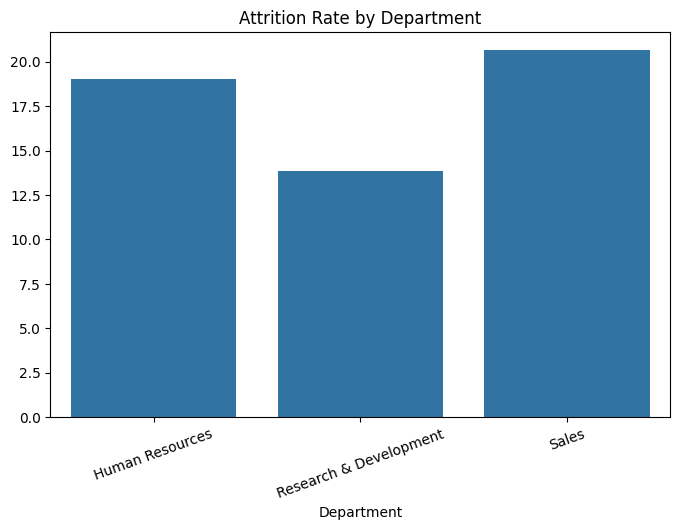

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values
)

plt.xticks(rotation=20)

plt.title("Attrition Rate by Department")

plt.show()

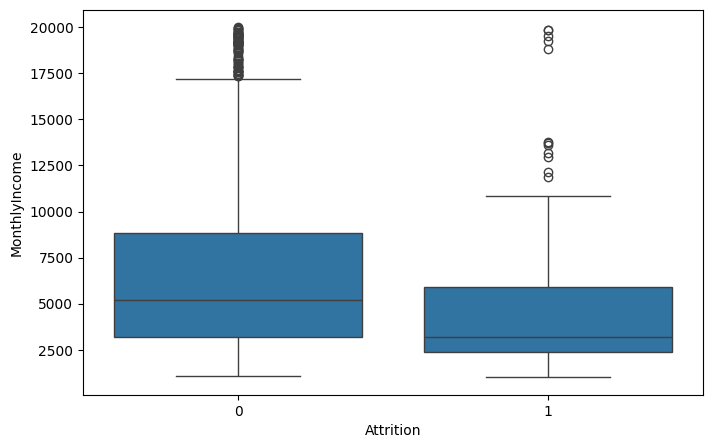

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.show()

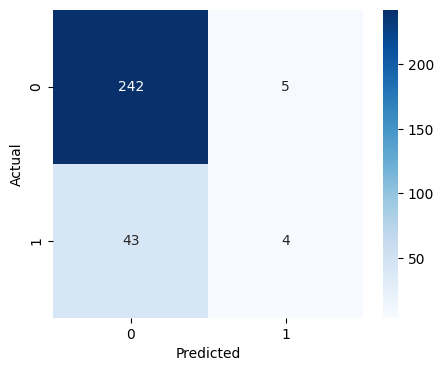

In [39]:
cm = confusion_matrix(y_test,rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [40]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.075157
0,Age,0.068066
16,TotalWorkingYears,0.053865
1,DailyRate,0.052450
19,YearsAtCompany,0.048968
10,MonthlyRate,0.047673
5,HourlyRate,0.044192
2,DistanceFromHome,0.043070
22,YearsWithCurrManager,0.042613
43,OverTime_Yes,0.042462


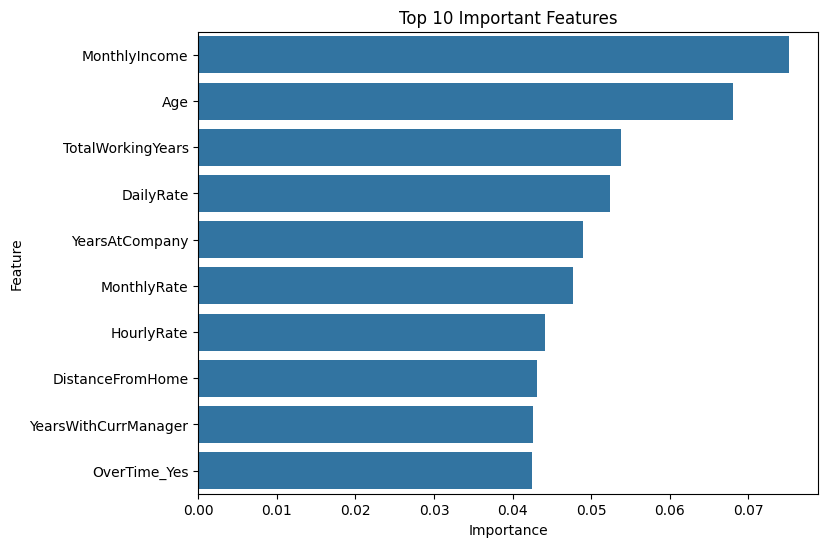

In [41]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

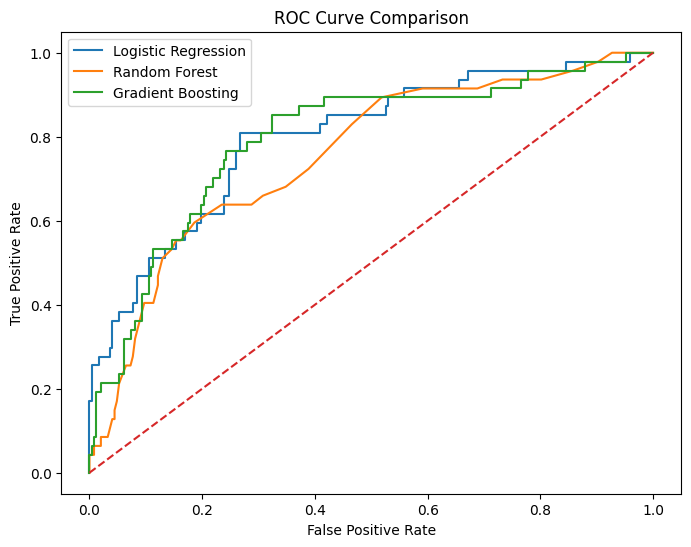

In [42]:
lr_fpr,lr_tpr,_ = roc_curve(y_test,lr_prob)

rf_fpr,rf_tpr,_ = roc_curve(y_test,rf_prob)

gb_fpr,gb_tpr,_ = roc_curve(y_test,gb_prob)

plt.figure(figsize=(8,6))

plt.plot(lr_fpr,lr_tpr,label="Logistic Regression")

plt.plot(rf_fpr,rf_tpr,label="Random Forest")

plt.plot(gb_fpr,gb_tpr,label="Gradient Boosting")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.title("ROC Curve Comparison")

plt.show()

In [ ]:
## Task 7 – HR Insights & Business Recommendations

Based on the machine learning model and exploratory data analysis, the three factors that most strongly predict employee attrition are **overtime**, **low job satisfaction**, and **fewer years at the company**. Employees who work overtime frequently and have lower job satisfaction are more likely to leave. The **Sales** department and job roles such as **Sales Representative** and **Laboratory Technician** show higher attrition rates and should be prioritized for employee retention efforts. Salary alone does not fully explain attrition. Although lower-paid employees tend to leave more often, factors such as work-life balance, job satisfaction, overtime, and career growth opportunities have a stronger influence on employee decisions. HR should conduct regular retention discussions with high-risk employees, especially those working overtime or with low satisfaction scores. The company should also improve work-life balance by reducing excessive overtime and providing clear career development opportunities. One limitation of this model is that it predicts attrition based only on historical employee data and cannot account for personal reasons, future organizational changes, or external factors that may influence an employee's decision to leave.
